In [4]:
# Install packages
!pip install mediapipe opencv-python pandas matplotlib

# Download the hand landmarker task file
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task \
     -O /content/hand_landmarker.task

from google.colab import drive
import os
import cv2
import csv
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Initialize MediaPipe Hand Landmarker (Tasks API)
BaseOptions = python.BaseOptions
HandLandmarker = vision.HandLandmarker
HandLandmarkerOptions = vision.HandLandmarkerOptions
VisionRunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='/content/hand_landmarker.task'),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=1
)

landmarker = HandLandmarker.create_from_options(options)


In [14]:
def show_sample(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Image not found.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

    results = landmarker.detect(mp_image)

    annotated_image = img_rgb.copy()
    h, w, _ = annotated_image.shape

    if results.hand_landmarks:
        for hand_landmarks in results.hand_landmarks:
            # Draw points
            for lm in hand_landmarks:
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.circle(annotated_image, (cx, cy), 5, (0, 255, 0), -1)

            # Draw connections manually
            connections = [
                (0,1),(1,2),(2,3),(3,4),
                (0,5),(5,6),(6,7),(7,8),
                (5,9),(9,10),(10,11),(11,12),
                (9,13),(13,14),(14,15),(15,16),
                (13,17),(17,18),(18,19),(19,20),
                (0,17)
            ]

            for start, end in connections:
                x1, y1 = int(hand_landmarks[start].x * w), int(hand_landmarks[start].y * h)
                x2, y2 = int(hand_landmarks[end].x * w), int(hand_landmarks[end].y * h)
                cv2.line(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 3)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(annotated_image)
    axes[1].set_title('MediaPipe Landmarks')
    axes[1].axis('off')

    plt.show()

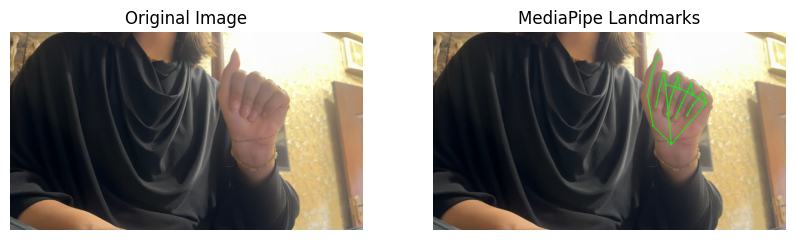

In [15]:
# Visualize a sample before processing everything (Change filename if needed)
sample_path = '/content/drive/MyDrive/ML-CEP/data/1/manahil/20.jpg'
if os.path.exists(sample_path):
    show_sample(sample_path)
else:
    print("Sample path does not exist, update the path to test visualization.")

In [ ]:
base = "/content/drive/MyDrive/ML-CEP"
data_path = os.path.join(base, "data")
csv_dir = os.path.join(base, "csv_data")
os.makedirs(csv_dir, exist_ok=True)

csv_file_path = os.path.join(csv_dir, "hand_landmarks_dataset.csv")
people = ["manahil", "sitwat", "talha", "Marium"]

headers = ['label', 'person']
for i in range(21):
    headers.extend([f'x{i}', f'y{i}', f'z{i}'])

total_processed = 0
total_skipped = 0
total_images = 0

# Count total images
for label in range(1, 27):
    for person in people:
        src_folder = os.path.join(data_path, str(label), person)
        if os.path.exists(src_folder):
            total_images += len(os.listdir(src_folder))

print(f"Total images found: {total_images}\n")

current = 0

with open(csv_file_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(headers)

    for label in range(1, 27):
        for person in people:
            src_folder = os.path.join(data_path, str(label), person)

            if not os.path.exists(src_folder):
                continue

            for file in os.listdir(src_folder):
                current += 1
                img_path = os.path.join(src_folder, file)

                img = cv2.imread(img_path)
                if img is None:
                    total_skipped += 1
                    continue

                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

                results = landmarker.detect(mp_image)

                if results.hand_landmarks:
                    landmarks = results.hand_landmarks[0]
                    row = [label, person]

                    for lm in landmarks:
                        row.extend([lm.x, lm.y, lm.z])

                    writer.writerow(row)
                    total_processed += 1
                else:
                    total_skipped += 1

                # Print progress every 100 images
                if current % 100 == 0 or current == total_images:
                    percent = (current / total_images) * 100
                    print(f"{current}/{total_images} ({percent:.1f}%) | Processed: {total_processed} | Skipped: {total_skipped}")

print("\n=== FINAL SUMMARY ===")
print(f"CSV saved at: {csv_file_path}")
print(f"Total Processed: {total_processed}")
print(f"Total Skipped: {total_skipped}")

Total images found: 5540

100/5540 (1.8%) | Processed: 98 | Skipped: 2
200/5540 (3.6%) | Processed: 197 | Skipped: 3
